In [9]:
# imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.io
from sklearn.decomposition import PCA
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

In [10]:
from matplotlib.font_manager import fontManager, FontProperties

path = "Figure_data/MYRIADPRO-REGULAR.OTF"
fontManager.addfont(path)
prop = FontProperties(fname=path)

## decompose of aesthetic agreement matrix

In [11]:
# load the stimulus images 
circleimages = np.load('Figure_data/circleimages.npy')
AAT_ratings = np.load('Figure_data/AAT_ratings.npy')
MAT_avg = np.load('Figure_data/MAT_avg_matrix.npy')

In [12]:
# exclude one participant with binary ratings
AAT_includes = AAT_ratings[:,0:33]
# group mean of AAT score
AATavg = np.mean(AAT_includes,axis=1)
AATstd = np.std(AAT_includes,axis=1)

In [13]:
res = np.corrcoef(AAT_includes)
pca_res = PCA(n_components=10)
pca_res.fit(res)
AAT_pc = pca_res.transform(res)

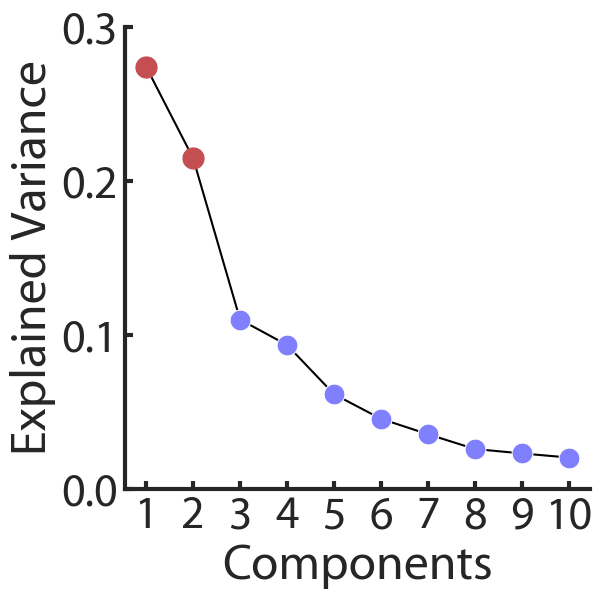

In [16]:
sns.set_context("talk")
sns.set(font_scale=3,style="ticks",rc={'figure.figsize':(6,6)},font=prop.get_name())
ax=sns.lineplot(x=range(1, len(pca_res.explained_variance_ratio_) + 1), y=pca_res.explained_variance_ratio_, markers=True,marker='o',markersize=15, markerfacecolor='#8080ff',color='black')
plt.plot(1, pca_res.explained_variance_ratio_[0], 'ro',markersize=15) # 'bo' means blue circle marker
plt.plot(2, pca_res.explained_variance_ratio_[1], 'ro',markersize=15) # 'bo' means blue circle marker

ax.set(xlabel='Components', ylabel='Explained Variance')
ax.set(xticks=[1,2,3,4,5,6,7,8,9,10])
ax.set(ylim=(0, 0.3), yticks=[0,0.1,0.2,0.3])
ax.tick_params(axis="y",direction="in", pad=5, width=3)
ax.tick_params(axis="x",direction="in", pad=5, width=3)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
sns.despine()

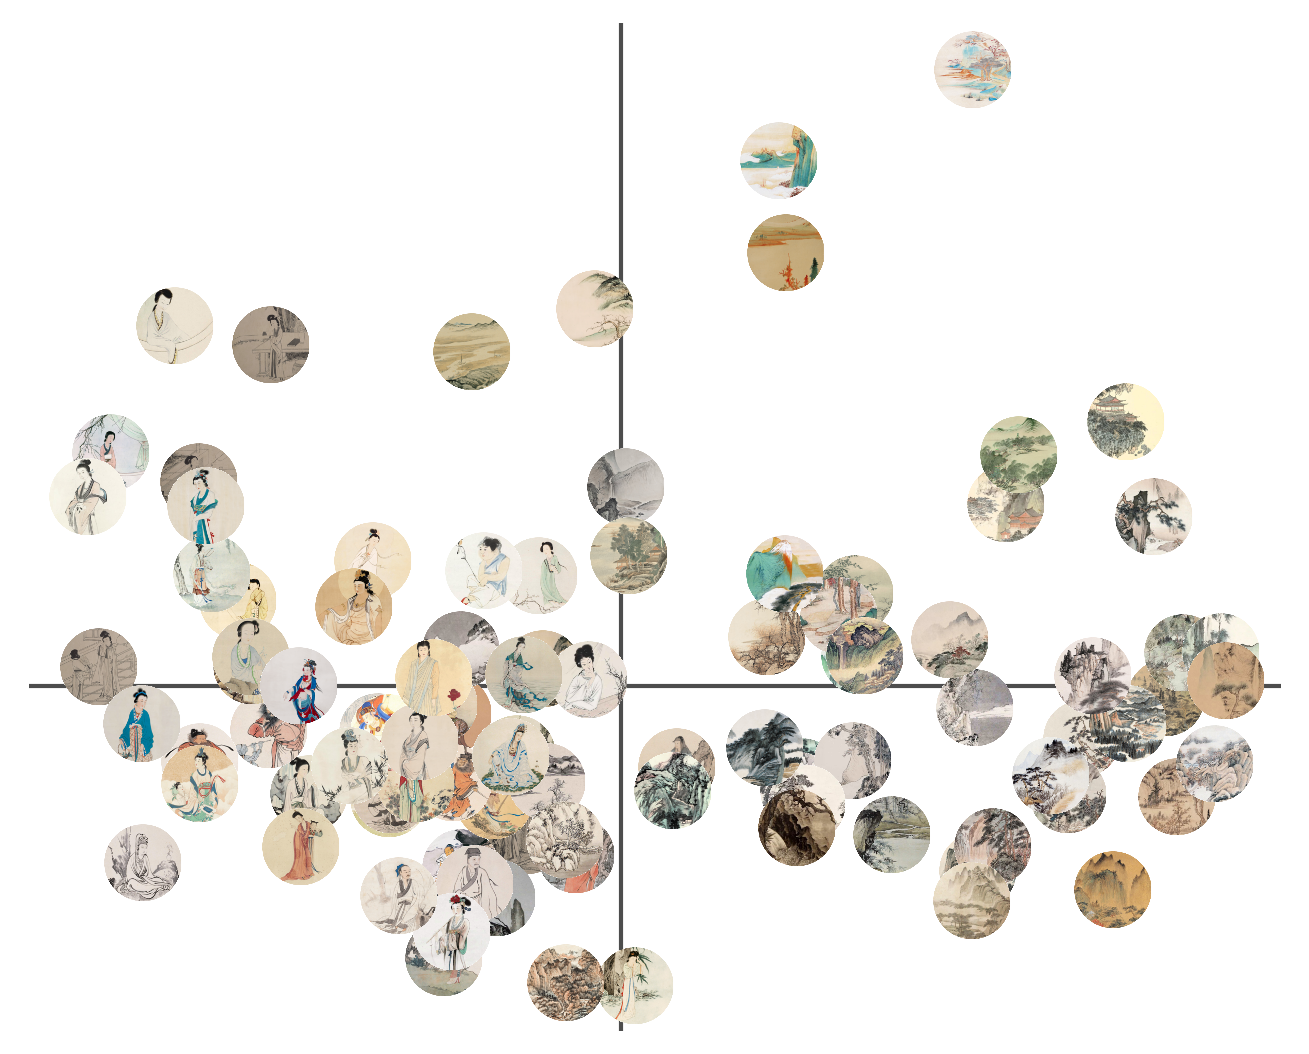

In [18]:
sns.set_style("white")
sns.set_context("talk")
fig, ax = plt.subplots(figsize=(15, 12))
ax.scatter(AAT_pc[:, 0], -AAT_pc[:, 1])
ax.set(xticklabels=[],xlabel=None,yticklabels=[],ylabel=None)
ax.axhline(0, color=".3", linewidth=3)
ax.axvline(0, color=".3", linewidth=3)
for x0, y0, img in zip(AAT_pc[:, 0], -AAT_pc[:, 1], circleimages):
    # set the background outside circle as transparent
    alpha = ~np.all(img == 255, axis=2) * 255
    img[:, :, 3] = alpha

    # plot single image
    im = OffsetImage(img, zoom=0.15)
    ab = AnnotationBbox(im, (x0, y0), frameon=False)
    ax.add_artist(ab)
plt.axis('on')
sns.despine(top=True, right=True, left=True, bottom=True)
plt.tight_layout()

## identify the cognitive associations with PCs

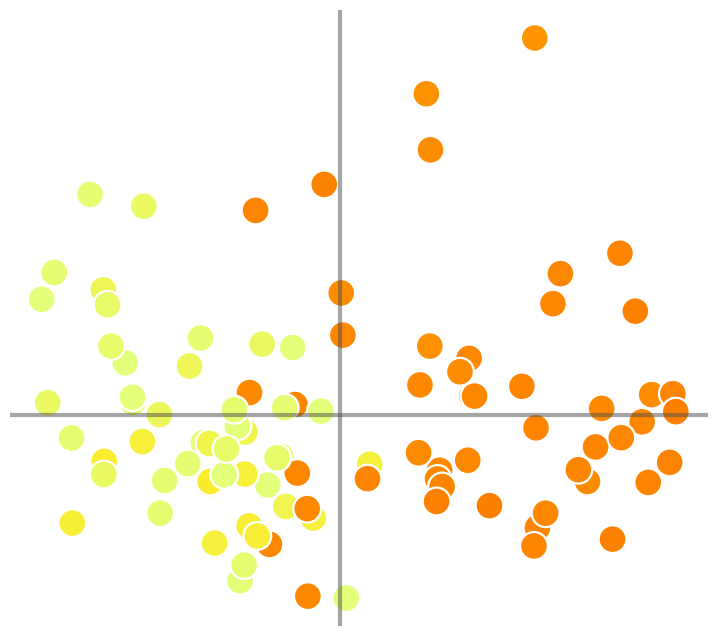

In [20]:
pca_MAT = PCA(n_components=10)
pca_MAT.fit(MAT_avg)
MAT_pc= pca_MAT.transform(MAT_avg)

sns.set_style("white")
sns.set_context("talk")
fig, ax = plt.subplots(figsize=(9,8))
#cmap = sns.color_palette("Spectral_r", as_cmap=True)
cmap = sns.color_palette("Wistia_r", as_cmap=True)
ax.axhline(0, color=".3", alpha=0.5, linewidth=3)
ax.axvline(0, color=".3", alpha=0.5, linewidth=3)
sns.scatterplot(x=AAT_pc[:,0], y=-AAT_pc[:,1], hue=MAT_pc[:,0],palette=cmap,s=400, hue_norm=(-7, 7),legend='brief',alpha=1)
#sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set(xticklabels=[],xlabel=None,yticklabels=[],ylabel=None)
ax.legend_.remove()
sns.despine(top=True, right=True, left=True, bottom=True)

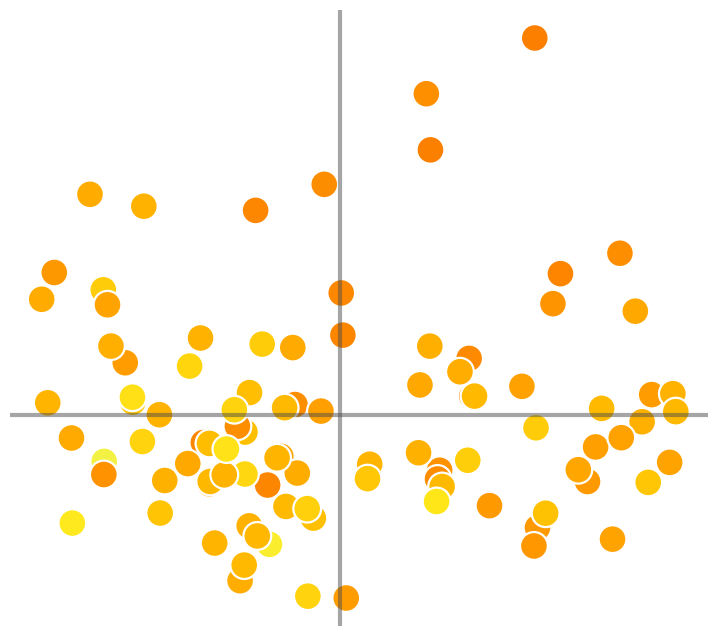

In [22]:
sns.set_style("white")
sns.set_context("talk")
cmap = sns.color_palette("Wistia", as_cmap=True)
fig, ax = plt.subplots(figsize=(9,8))
ax.axhline(0, color=".3", alpha=0.5, linewidth=3)
ax.axvline(0, color=".3", alpha=0.5, linewidth=3)
sns.scatterplot(x=AAT_pc[:,0], y=-AAT_pc[:,1], hue=AATavg,palette=cmap,s=400, hue_norm=(1.3, 1.7))
#sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.legend_.remove()
ax.set(xticklabels=[],xlabel=None,yticklabels=[],ylabel=None)
sns.despine(top=True, right=True, left=True, bottom=True)

In [23]:
AIscore = scipy.io.loadmat('Figure_data/MUSIQ_AVA_score.mat')

In [24]:
df_dims = pd.DataFrame({'A_avg':AATavg,'A_std':AATstd,
                       'AAT_pc1':AAT_pc[:,0],'AAT_pc2':-AAT_pc[:,1],
                       'MAT_pc1':-MAT_pc[:,0],'MAT_pc2':MAT_pc[:,1],
                       'Category':np.tile(np.repeat(['Portrait','Landscape'],12),4),
                       'Artists':np.repeat(['A1','A2','A3','A4'],24),
                       'AIscore':AIscore['AIscore'][:,0]})

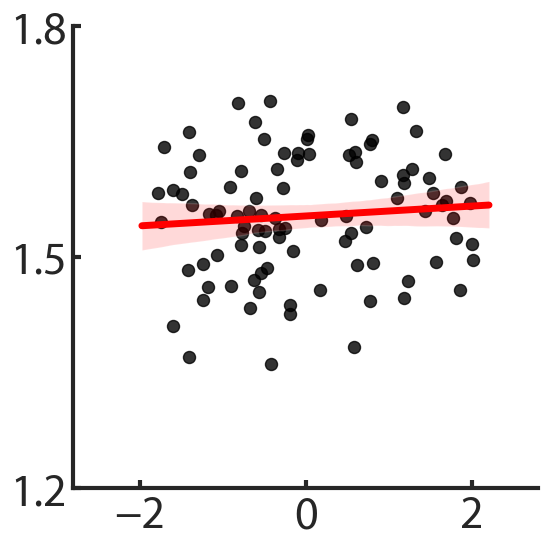

In [26]:
sns.set_context("talk")
sns.set(font_scale=3,style="ticks",rc={'figure.figsize':(6,6)},font=prop.get_name())
ax=sns.regplot(data=df_dims,x='AAT_pc1',y='A_avg',y_partial='MAT_pc1', color="black",marker='.',scatter_kws={'s':300}, line_kws={"color": "red","linewidth":5},ci = 95,truncate = False)
ax.set(xlabel='', ylabel='')
ax.set(xlim=(-2.8, 2.8), xticks=[-2,0,2])
ax.set(ylim=(1.2, 1.8), yticks=[1.2,1.5,1.8])
ax.tick_params(axis="y",direction="in", pad=5,width=3)
ax.tick_params(axis="x",direction="in", pad=5,width=3)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
sns.despine()

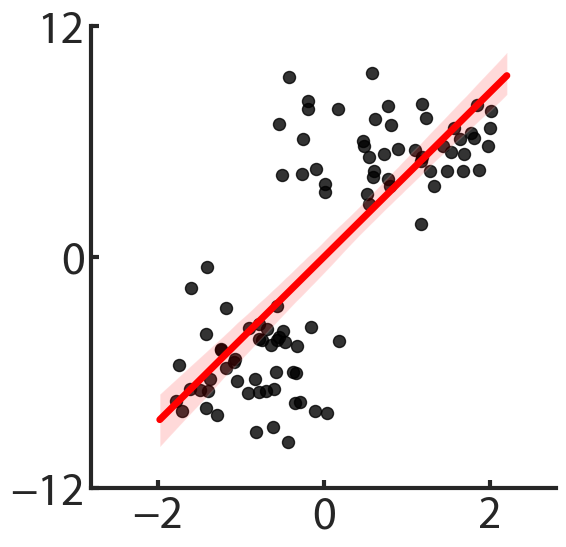

In [27]:
sns.set_context("talk")
sns.set(font_scale=3,style="ticks",rc={'figure.figsize':(6,6)},font=prop.get_name())
ax=sns.regplot(data=df_dims,x='AAT_pc1',y='MAT_pc1',y_partial='A_avg',color="black",marker='.',scatter_kws={'s':300}, line_kws={"color": "red","linewidth":5},ci = 95,truncate = False)
ax.set(xlabel='', ylabel='')
ax.set(xlim=(-2.8, 2.8), xticks=[-2,0,2])
ax.set(ylim=(-12, 12), yticks=[-12,0,12])
ax.tick_params(axis="y",direction="in", pad=5, width=3)
ax.tick_params(axis="x",direction="in", pad=5, width=3)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
sns.despine()

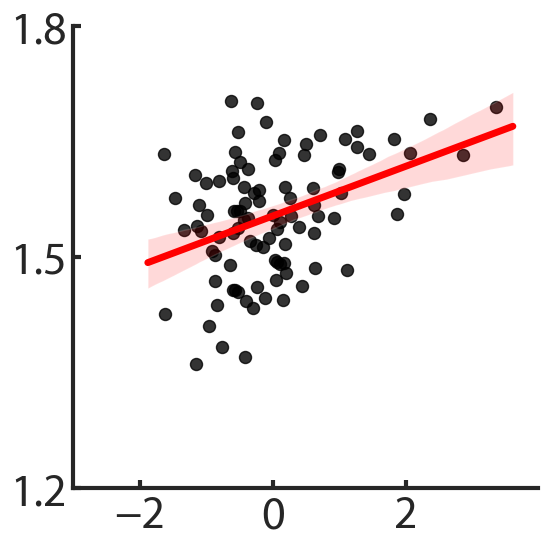

In [28]:
sns.set_context("talk")
sns.set(font_scale=3,style="ticks",rc={'figure.figsize':(6,6)},font=prop.get_name())
ax=sns.regplot(data=df_dims,x='AAT_pc2',y='A_avg',y_partial='MAT_pc1',color="black",marker='.',scatter_kws={'s':300}, line_kws={"color": "red","linewidth":5},ci = 95,truncate = False)
ax.set(xlabel='', ylabel='')
ax.set(xlim=(-3, 4), xticks=[-2,0,2])
ax.set(ylim=(1.2, 1.8), yticks=[1.2,1.5,1.8])
ax.tick_params(axis="y",direction="in", pad=5, width=3)
ax.tick_params(axis="x",direction="in", pad=5, width=3)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
sns.despine()

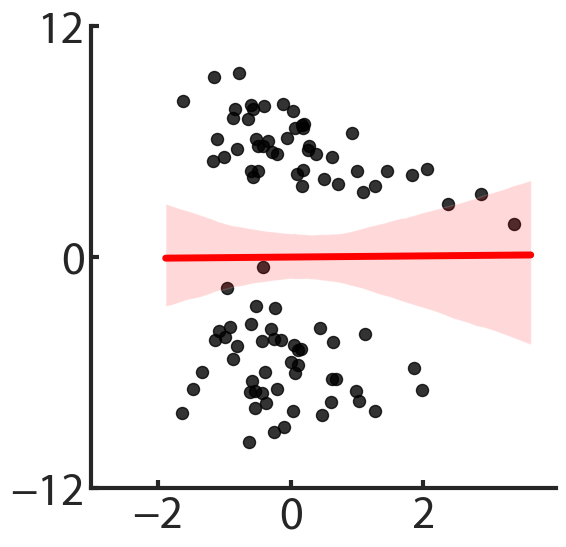

In [29]:
sns.set_context("talk")
sns.set(font_scale=3,style="ticks",rc={'figure.figsize':(6,6)},font=prop.get_name())
ax=sns.regplot(data=df_dims,x='AAT_pc2',y='MAT_pc1',y_partial='A_avg',color="black",marker='.',scatter_kws={'s':300}, line_kws={"color": "red","linewidth":5},ci = 95,truncate = False)
ax.set(xlabel='', ylabel='')
ax.set(xlim=(-3, 4), xticks=[-2,0,2])
ax.set(ylim=(-12, 12), yticks=[-12,0,12])
ax.tick_params(axis="y",direction="in", pad=5, width=3)
ax.tick_params(axis="x",direction="in", pad=5, width=3)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
sns.despine()

## association with AI generated aesthetic quality score

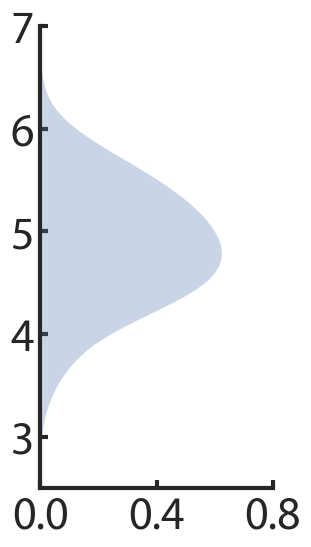

In [30]:
sns.set_context("talk")
sns.set(font_scale=3,style="ticks",rc={'figure.figsize':(3,6)},font=prop.get_name())
ax = sns.kdeplot(data=df_dims,y ='AIscore',legend=False,bw_adjust=1.5,fill=True, alpha=.3, linewidth=0)
ax.set(ylim=(2.5,7), yticks=[3,4,5,6,7])
ax.set(xlim=(0,0.8), xticks=[0,0.4,0.8])
ax.set(xlabel='', ylabel='')
ax.tick_params(axis="y",direction="in", pad=5)
ax.tick_params(axis="x",direction="in", pad=5)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.tick_params(width=3)
sns.despine()

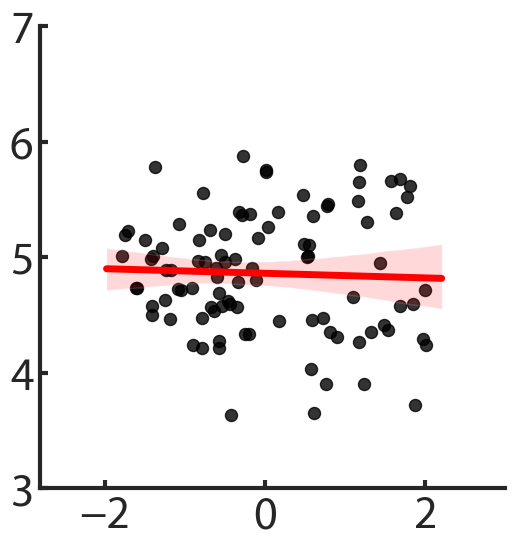

In [31]:
sns.set_context("talk")
sns.set(font_scale=3,style="ticks",rc={'figure.figsize':(6,6)},font=prop.get_name())
ax=sns.regplot(data=df_dims,x='AAT_pc1',y='AIscore',y_partial='MAT_pc1', color="black",marker='.',scatter_kws={'s':300}, line_kws={"color": "red","linewidth":5},ci = 95,truncate = False)
ax.set(xlabel='', ylabel='')
ax.set(xlim=(-2.8, 3), xticks=[-2,0,2])
ax.set(ylim=(3, 7), yticks=[3,4,5,6,7])
ax.tick_params(axis="y",direction="in", pad=5,width=3)
ax.tick_params(axis="x",direction="in", pad=5,width=3)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
sns.despine()

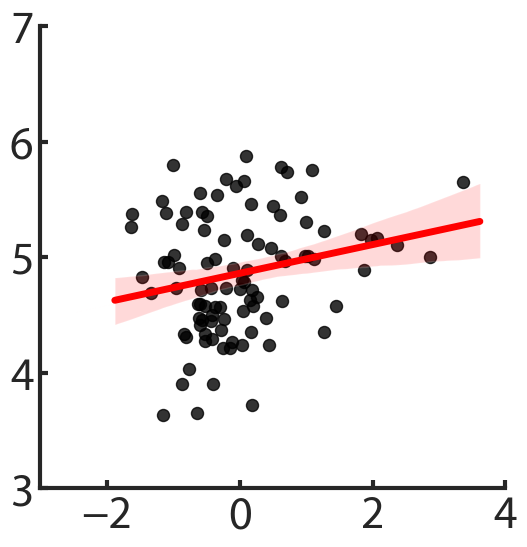

In [32]:
sns.set_context("talk")
sns.set(font_scale=3,style="ticks",rc={'figure.figsize':(6,6)},font=prop.get_name())
ax=sns.regplot(data=df_dims,x='AAT_pc2',y='AIscore',y_partial='MAT_pc1', color="black",marker='.',scatter_kws={'s':300}, line_kws={"color": "red","linewidth":5},ci = 95,truncate = False)
ax.set(xlabel='', ylabel='')
ax.set(xlim=(-3, 4), xticks=[-2,0,2,4])
ax.set(ylim=(3, 7), yticks=[3,4,5,6,7])
ax.tick_params(axis="y",direction="in", pad=5,width=3)
ax.tick_params(axis="x",direction="in", pad=5,width=3)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
sns.despine()